# Dataset Feature Exploration

This notebook explores the characteristics of all synthetic datasets to understand:
1. Feature distributions
2. Pairwise correlations and scatter plots
3. Differences between datasets with/without confounders
4. Why causal discovery performs differently across datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Directories
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
DATA_DIR = BASE_DIR / 'data'
SYNTHETIC_DIR = DATA_DIR / 'synthetic'
PROCESSED_DIR = DATA_DIR / 'processed'

# Dataset configurations
DATASETS = [
    'linear_no_conf_f50_s1000_p30',
    'linear_conf_f50_s1000_p30',
    # 'nonlinear_no_conf_f50_s1000_p30',
    # 'nonlinear_conf_f50_s1000_p30',
    # 'mixed_no_conf_f50_s1000_p30',
    # 'mixed_conf_f50_s1000_p30'
]

print("✅ Setup complete!")

✅ Setup complete!


---
## 1. Overall Dataset Statistics

First, let's get a high-level view of each dataset's characteristics.

In [2]:
# Collect statistics for all datasets
stats_list = []

for dataset in DATASETS:
    # Load train data
    train_path = PROCESSED_DIR / f"{dataset}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    
    # Calculate correlation matrix
    corr = X.corr()
    upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_values = upper_tri.stack().values
    
    stats_list.append({
        'dataset': dataset,
        'n_samples': len(data),
        'n_features': X.shape[1],
        'mean_value': X.values.mean(),
        'std_value': X.values.std(),
        'min_value': X.values.min(),
        'max_value': X.values.max(),
        'mean_abs_corr': np.abs(corr_values).mean(),
        'median_abs_corr': np.median(np.abs(corr_values)),
        'max_abs_corr': np.abs(corr_values).max(),
        'pct_strong_corr_03': (np.abs(corr_values) > 0.3).sum() / len(corr_values) * 100,
        'pct_strong_corr_05': (np.abs(corr_values) > 0.5).sum() / len(corr_values) * 100,
    })

stats_df = pd.DataFrame(stats_list)
print("\n📊 DATASET STATISTICS SUMMARY")
print("=" * 100)
display(stats_df.round(4))


📊 DATASET STATISTICS SUMMARY


,dataset,n_samples,n_features,mean_value,std_value,min_value,max_value,mean_abs_corr,median_abs_corr,max_abs_corr,pct_strong_corr_03,pct_strong_corr_05
0,linear_no_conf_f50_s1000_p30,800,50,-0.0011,0.8991,-4.0919,4.2621,NaN,NaN,NaN,3.68,2.48
1,linear_conf_f50_s1000_p30,800,50,-0.0149,0.9657,-4.6820,4.0090,NaN,NaN,NaN,4.40,2.76


### Correlation Distribution Comparison

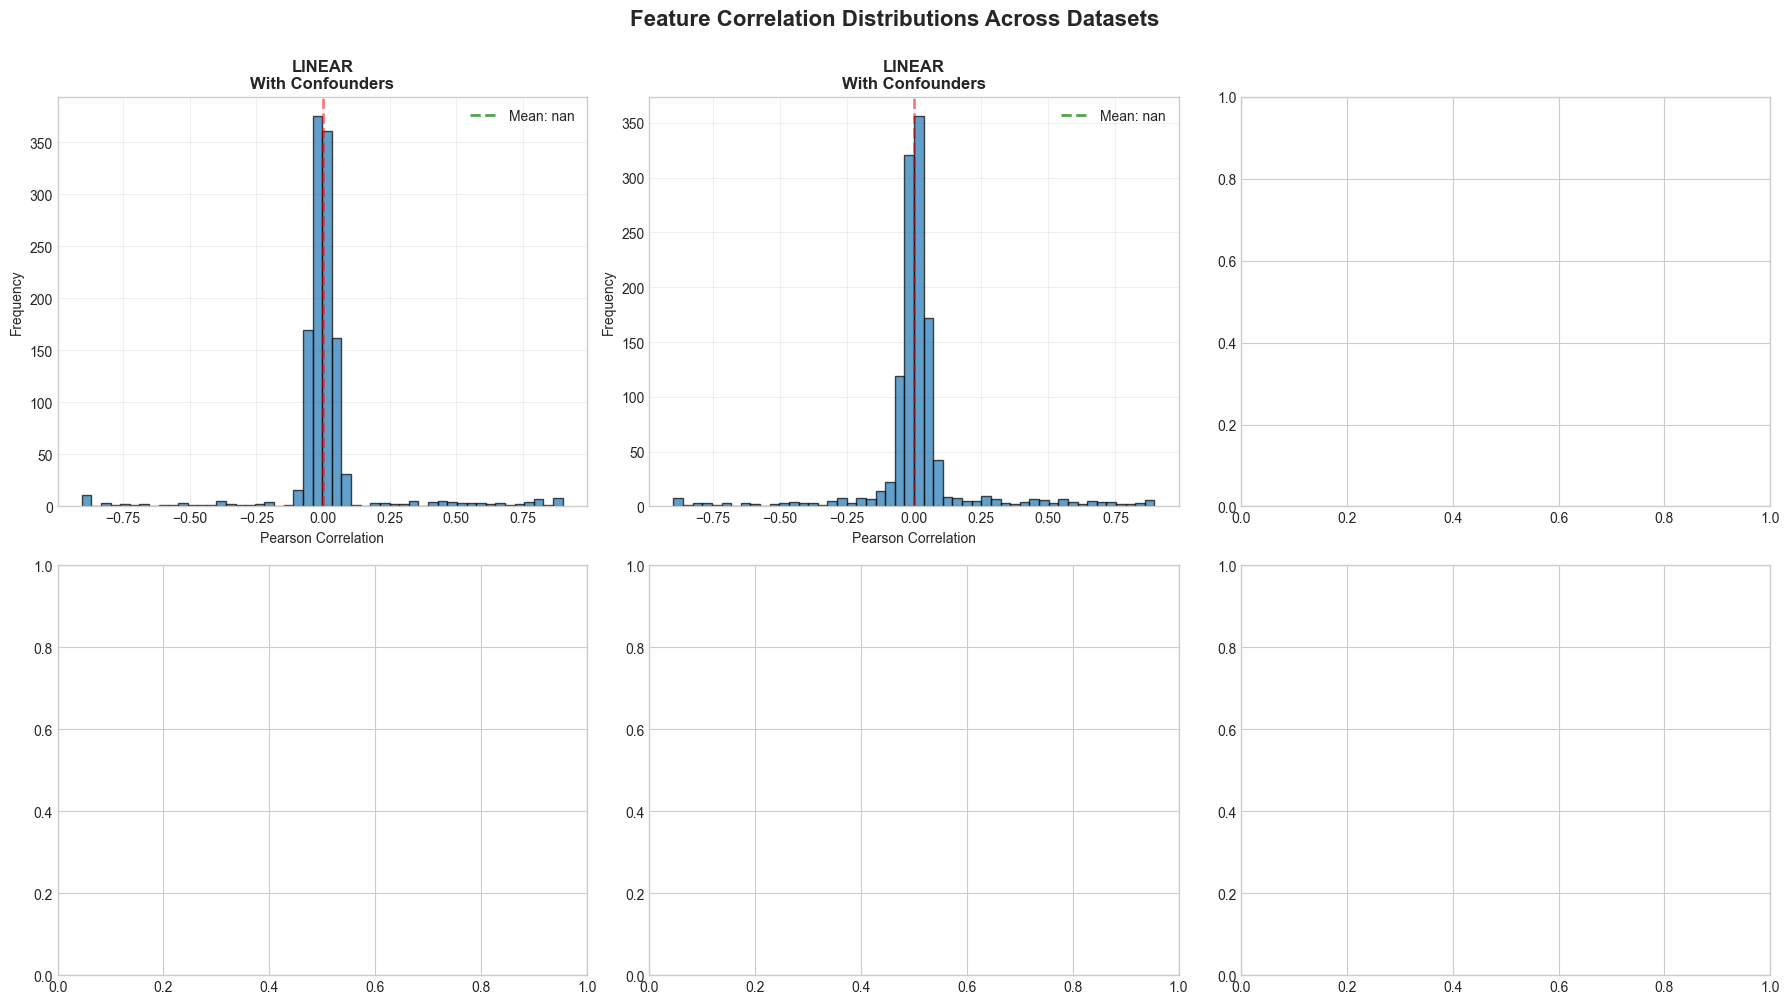


📈 KEY OBSERVATIONS:

LINEAR System:
  No Confounders:   Mean |corr| = nan, Max = nan
  With Confounders: Mean |corr| = nan, Max = nan
  → Ratio: nanx stronger with confounders


In [3]:
# Create correlation distribution plots for all datasets
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    # Load data
    train_path = PROCESSED_DIR / f"{dataset}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    
    # Calculate correlations
    corr = X.corr()
    upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_values = upper_tri.stack().values
    
    # Plot histogram
    ax = axes[idx]
    ax.hist(corr_values, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(corr_values.mean(), color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Mean: {corr_values.mean():.3f}')
    
    system_type = dataset.split('_')[0]
    conf_type = 'With Confounders' if 'conf_f' in dataset else 'No Confounders'
    
    ax.set_title(f'{system_type.upper()}\n{conf_type}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pearson Correlation')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Correlation Distributions Across Datasets', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print comparison
print("\n📈 KEY OBSERVATIONS:")
print("=" * 80)
for i in range(0, len(DATASETS), 2):
    no_conf = stats_df.iloc[i]
    conf = stats_df.iloc[i+1]
    system = no_conf['dataset'].split('_')[0]
    print(f"\n{system.upper()} System:")
    print(f"  No Confounders:   Mean |corr| = {no_conf['mean_abs_corr']:.4f}, Max = {no_conf['max_abs_corr']:.4f}")
    print(f"  With Confounders: Mean |corr| = {conf['mean_abs_corr']:.4f}, Max = {conf['max_abs_corr']:.4f}")
    print(f"  → Ratio: {conf['mean_abs_corr'] / no_conf['mean_abs_corr']:.2f}x stronger with confounders")

---
## 2. Pairwise Feature Scatter Plots

Let's visualize relationships between adjacent features for each dataset.
We'll sample a subset of features to keep the visualization manageable.


📊 Creating pairplot for linear_no_conf_f50_s1000_p30...


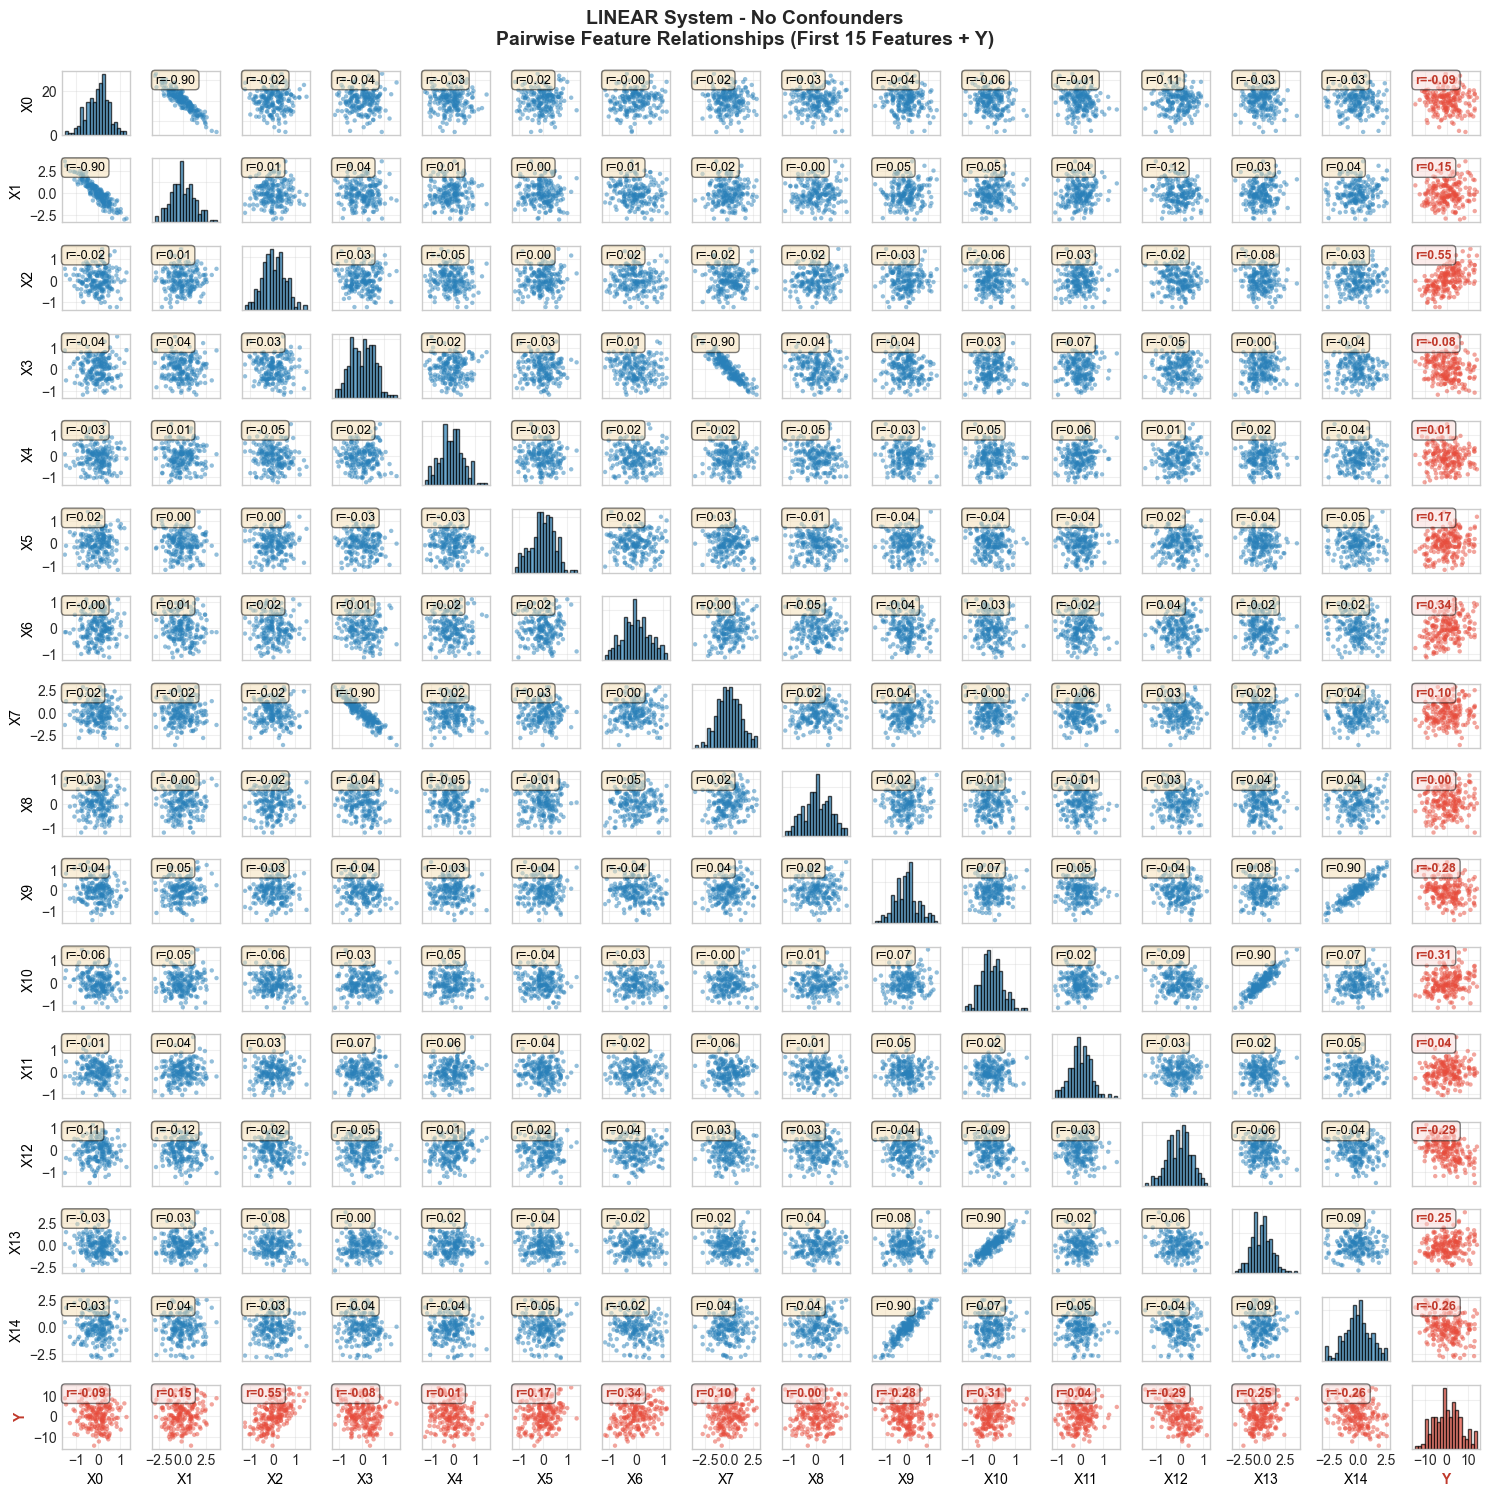


📊 Creating pairplot for linear_conf_f50_s1000_p30...


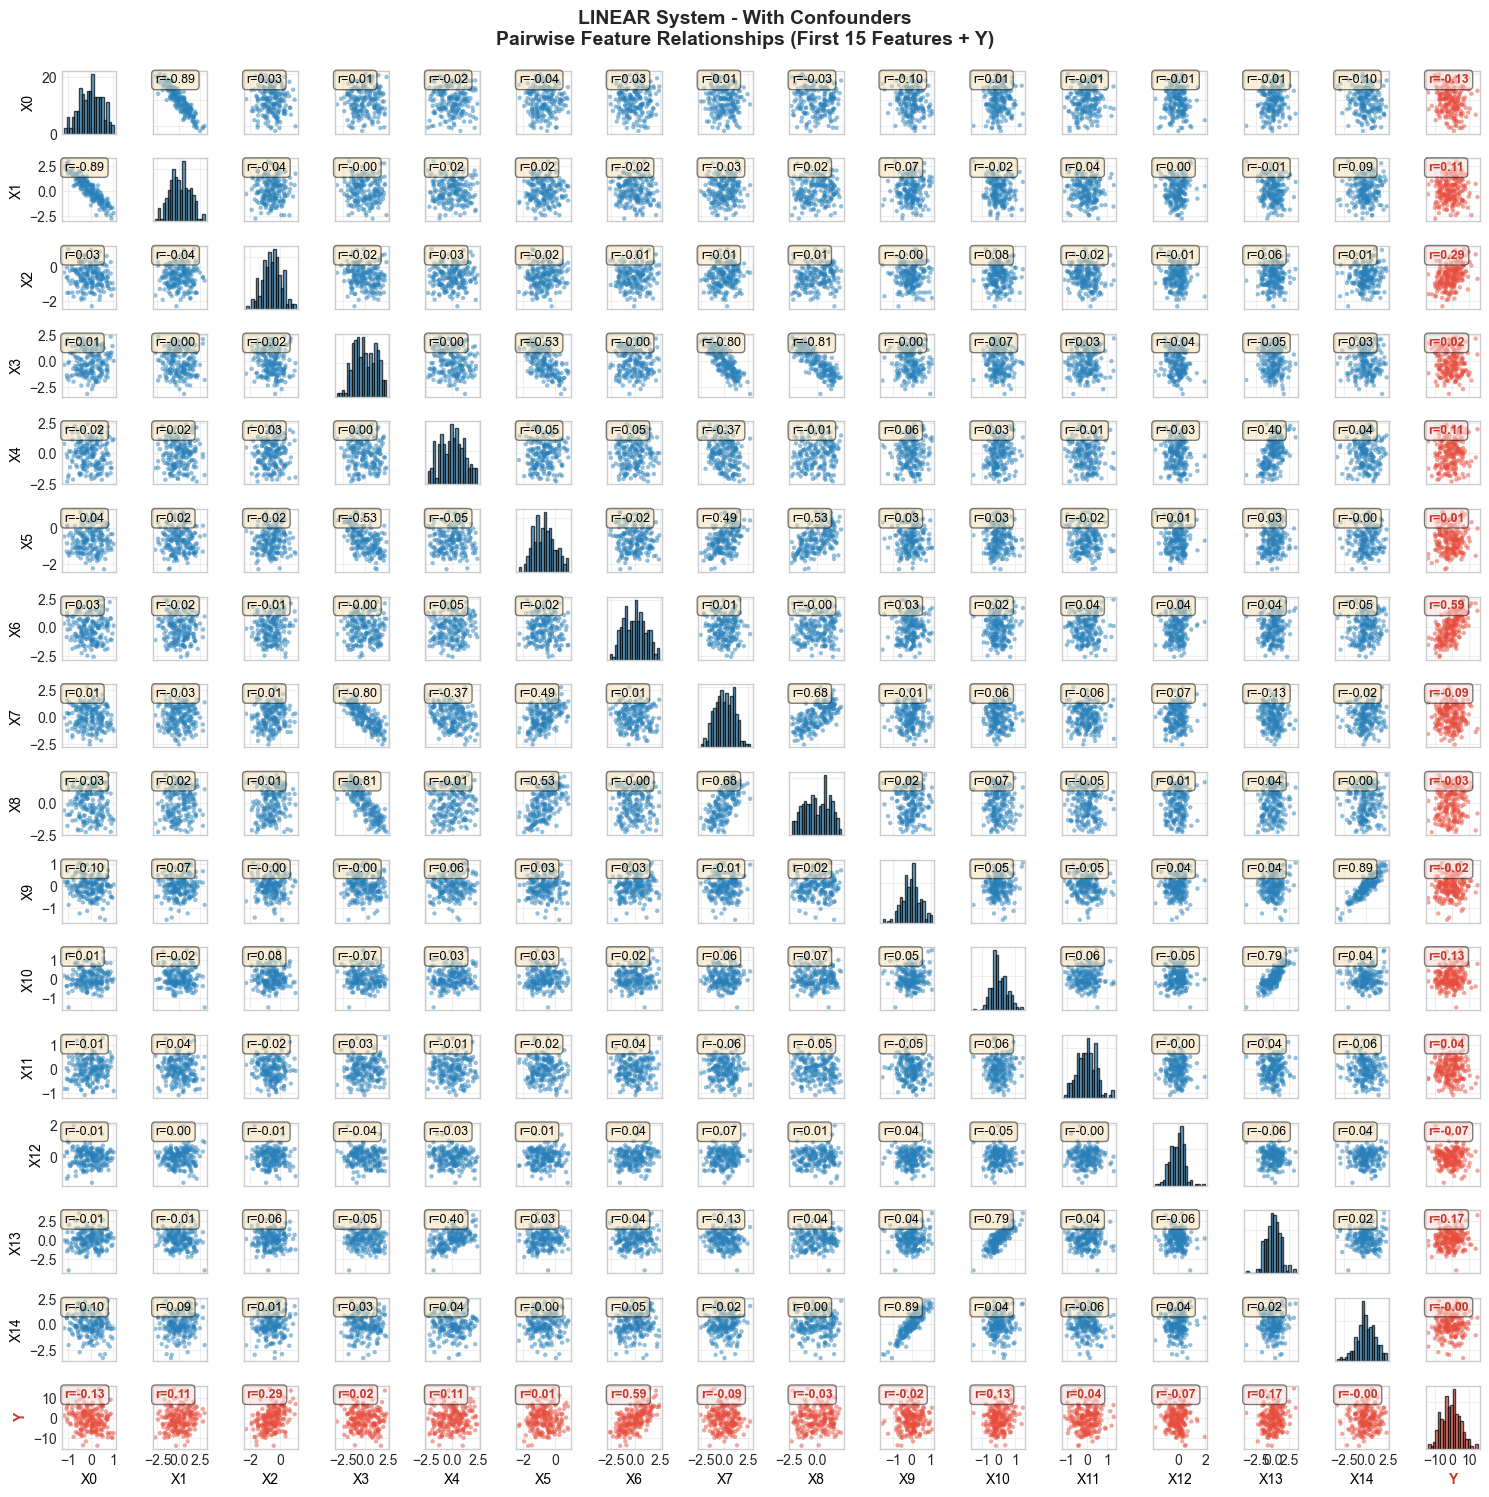

In [4]:
def plot_feature_pairs(dataset_name, n_features_to_show=6, sample_size=200):
    """
    Plot scatter plots for consecutive feature pairs, with Y as the last row/column.
    
    Parameters:
    -----------
    dataset_name : str
        Dataset name
    n_features_to_show : int
        Number of X features to include in visualization
    sample_size : int
        Number of samples to plot
    """
    # Load data
    train_path = PROCESSED_DIR / f"{dataset_name}_train.parquet"
    data = pd.read_parquet(train_path)
    X = data.drop(columns=['Y'])
    y = data['Y']

    # Sample data for plotting
    sample_idx = X.sample(n=min(sample_size, len(X)), random_state=42).index
    X_sample = X.loc[sample_idx]
    y_sample = y.loc[sample_idx]

    # Select features (first n_features_to_show X features + Y last)
    x_features  = X.columns[:n_features_to_show].tolist()
    all_features = x_features + ['Y']

    # Combined DataFrames for plotting and correlation (full data)
    df_plot = X_sample[x_features].copy()
    df_plot['Y'] = y_sample.values
    df_full = X[x_features].copy()
    df_full['Y'] = y.values

    # Create pairplot-style grid
    n = len(all_features)
    fig, axes = plt.subplots(n, n, figsize=(15, 15))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            fi, fj = all_features[i], all_features[j]

            is_y_row = (fi == 'Y')
            is_y_col = (fj == 'Y')
            point_color = '#e74c3c' if (is_y_row or is_y_col) else '#2980b9'

            if i == j:
                # Diagonal: histogram
                color = '#e74c3c' if fi == 'Y' else '#2980b9'
                ax.hist(df_plot[fi], bins=20, alpha=0.7, edgecolor='black', color=color)
            else:
                # Off-diagonal: scatter plot
                ax.scatter(df_plot[fj], df_plot[fi],
                           alpha=0.5, s=10, edgecolors='none', color=point_color)

                # Calculate and display correlation
                corr = df_full[fj].corr(df_full[fi])
                ax.text(0.05, 0.95, f'r={corr:.2f}',
                        transform=ax.transAxes,
                        fontsize=9,
                        verticalalignment='top',
                        color='#c0392b' if (is_y_row or is_y_col) else 'black',
                        fontweight='bold' if (is_y_row or is_y_col) else 'normal',
                        bbox=dict(boxstyle='round',
                                  facecolor='#fadbd8' if (is_y_row or is_y_col) else 'wheat',
                                  alpha=0.5))

            # Labels
            if i == n - 1:
                ax.set_xlabel(fj, fontsize=10,
                              color='#c0392b' if fj == 'Y' else 'black',
                              fontweight='bold' if fj == 'Y' else 'normal')
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(fi, fontsize=10,
                              color='#c0392b' if fi == 'Y' else 'black',
                              fontweight='bold' if fi == 'Y' else 'normal')
            else:
                ax.set_yticklabels([])

            ax.grid(True, alpha=0.3)

    system_type = dataset_name.split('_')[0]
    conf_type = 'With Confounders' if '_no_conf_' not in dataset_name else 'No Confounders'
    plt.suptitle(f'{system_type.upper()} System - {conf_type}\nPairwise Feature Relationships (First {n_features_to_show} Features + Y)',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig

# Create plots for all datasets
for dataset in DATASETS:
    print(f"\n📊 Creating pairplot for {dataset}...")
    fig = plot_feature_pairs(dataset, n_features_to_show=15, sample_size=200)
    plt.show()
    plt.close(fig)


---
## 3. Comparative Analysis: Mixed Systems

Deep dive into the mixed systems to understand the dramatic difference.

In [5]:
# Load both mixed datasets
mixed_no_conf = pd.read_parquet(PROCESSED_DIR / 'mixed_no_conf_f50_s1000_p50_train.parquet')
mixed_conf = pd.read_parquet(PROCESSED_DIR / 'mixed_conf_f50_s1000_p50_train.parquet')

X_no_conf = mixed_no_conf.drop(columns=['Y'])
X_conf = mixed_conf.drop(columns=['Y'])

# Calculate correlations
corr_no_conf = X_no_conf.corr()
corr_conf = X_conf.corr()

print("\n🔬 DETAILED COMPARISON: MIXED SYSTEMS")
print("=" * 80)

# Get correlation values (upper triangle)
upper_tri_no_conf = corr_no_conf.where(np.triu(np.ones(corr_no_conf.shape), k=1).astype(bool))
upper_tri_conf = corr_conf.where(np.triu(np.ones(corr_conf.shape), k=1).astype(bool))

corr_vals_no_conf = upper_tri_no_conf.stack().values
corr_vals_conf = upper_tri_conf.stack().values

print(f"\nNo Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_no_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_no_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_no_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_no_conf) > 0.1).sum() / len(corr_vals_no_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_no_conf) > 0.3).sum() / len(corr_vals_no_conf) * 100:.1f}%")

print(f"\nWith Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_conf) > 0.1).sum() / len(corr_vals_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_conf) > 0.3).sum() / len(corr_vals_conf) * 100:.1f}%")

print(f"\n⚠️  Ratio (with/without confounders): {np.abs(corr_vals_conf).mean() / np.abs(corr_vals_no_conf).mean():.2f}x")


🔬 DETAILED COMPARISON: MIXED SYSTEMS

No Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 34.5%
  % with |corr| > 0.3: 15.2%

With Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 31.2%
  % with |corr| > 0.3: 12.1%

⚠️  Ratio (with/without confounders): nanx


### Side-by-Side Correlation Heatmaps

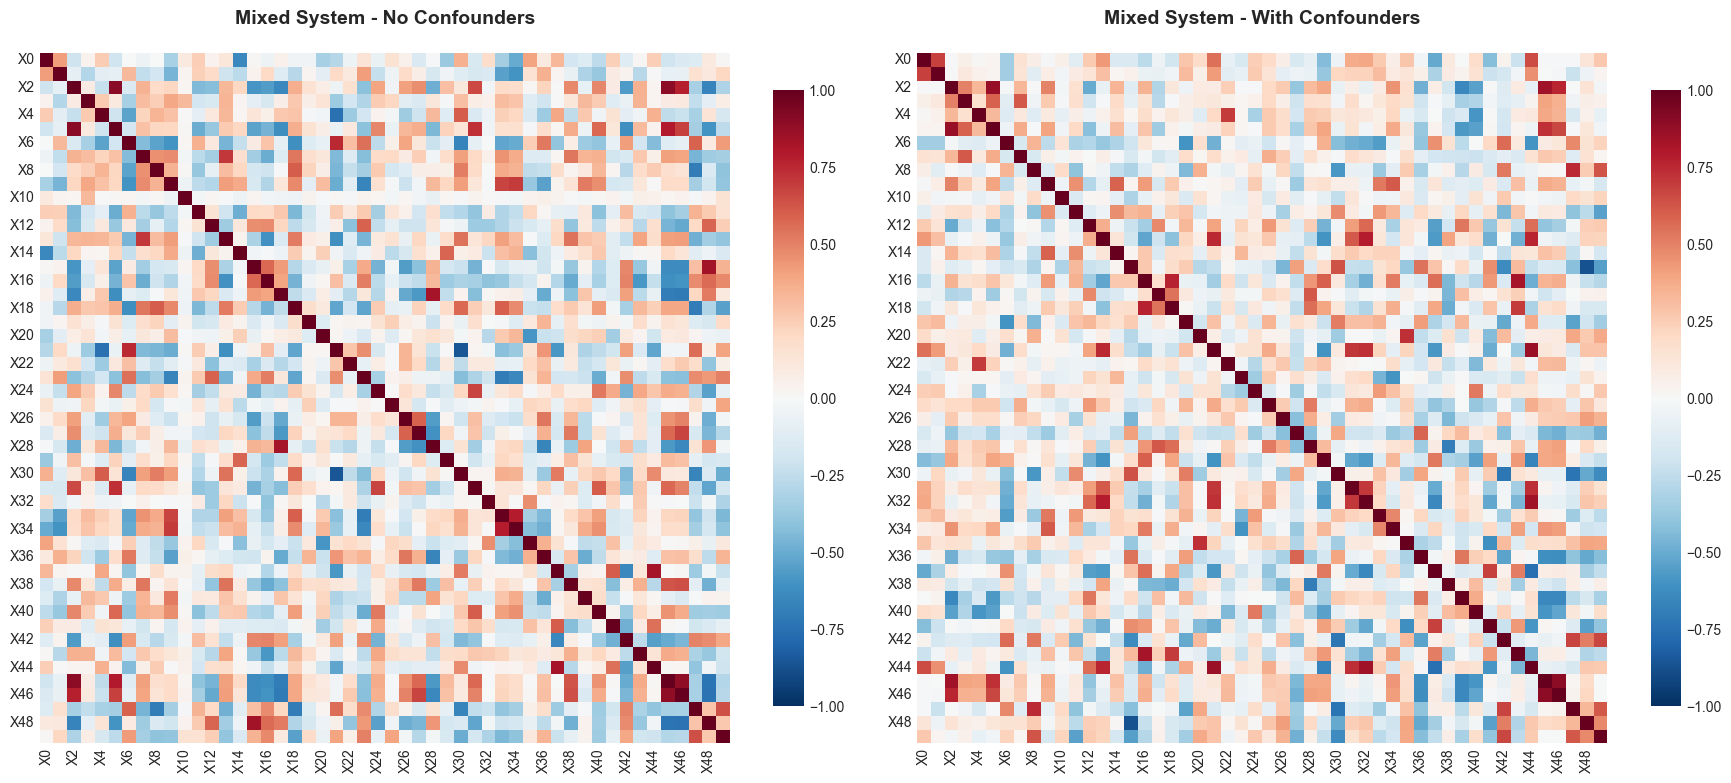

In [6]:
# Create side-by-side heatmaps for first 20 features
n_features_show = 50

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# No confounders
sns.heatmap(corr_no_conf.iloc[:n_features_show, :n_features_show], 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Mixed System - No Confounders\n', fontsize=14, fontweight='bold')

# With confounders
sns.heatmap(corr_conf.iloc[:n_features_show, :n_features_show], 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Mixed System - With Confounders\n', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribution of Feature Values

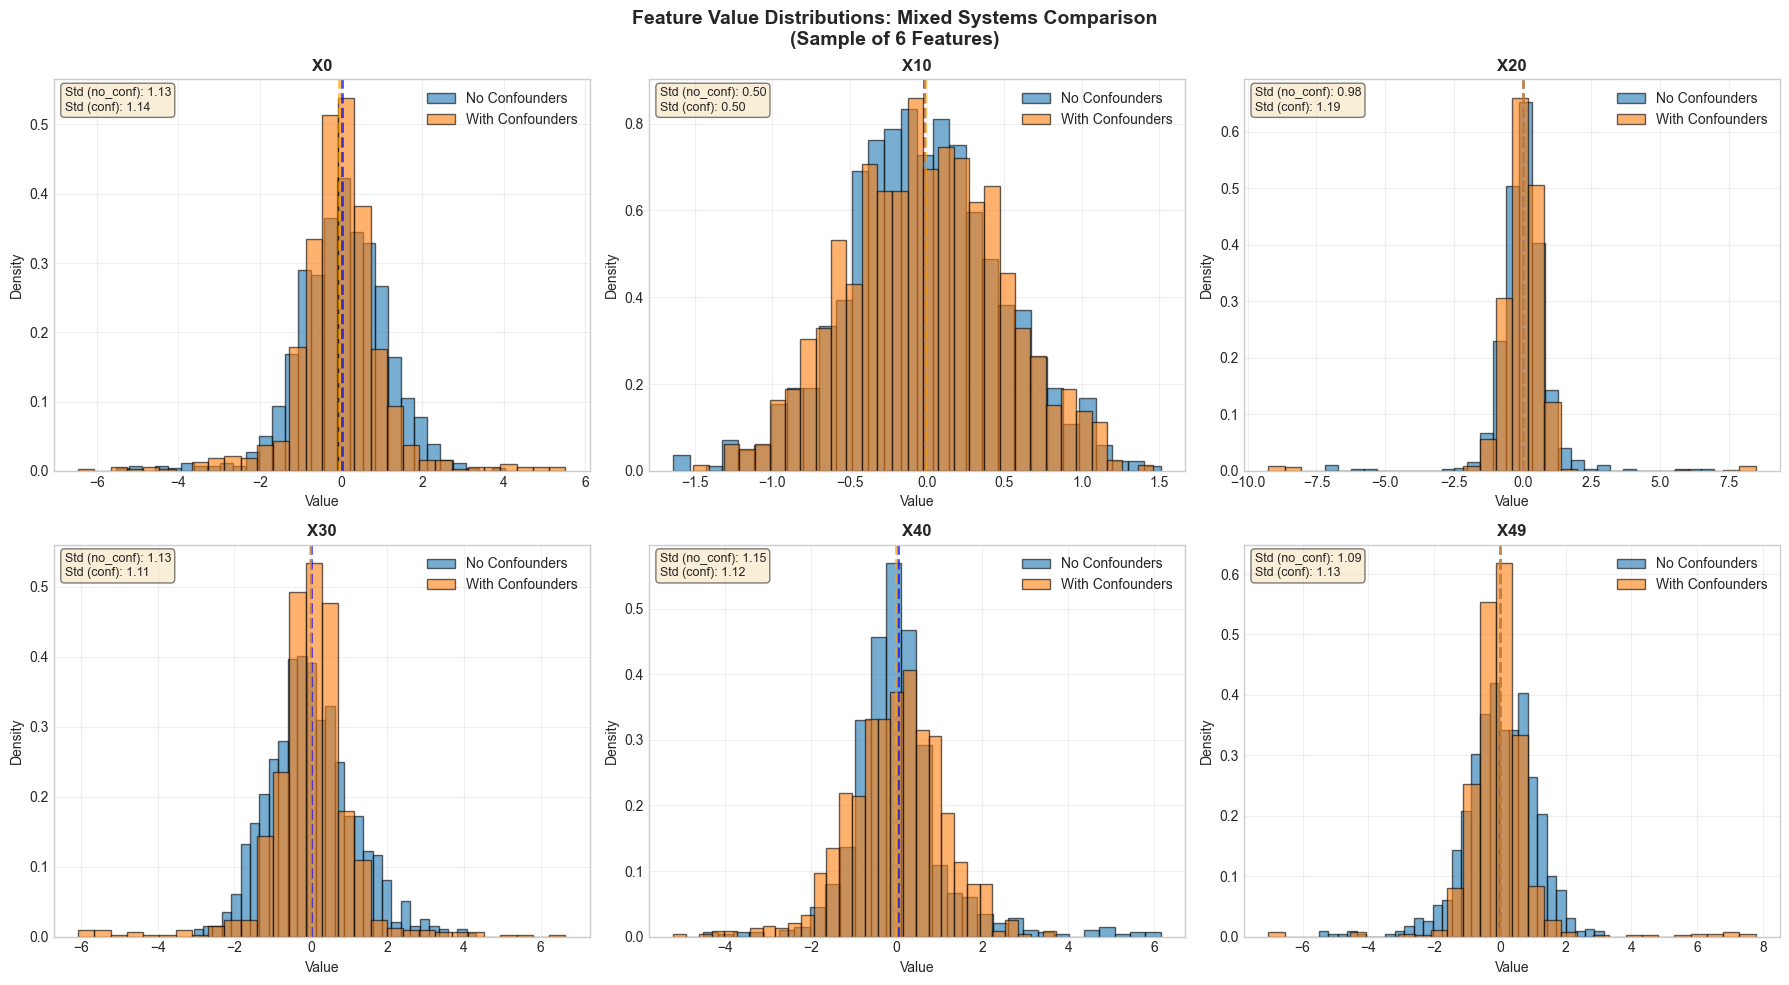

In [7]:
# Compare feature value distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sample 6 features to compare
features_to_plot = [f'X{i}' for i in [0, 10, 20, 30, 40, 49]]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Plot both distributions
    ax.hist(X_no_conf[feature], bins=30, alpha=0.6, label='No Confounders', 
            edgecolor='black', density=True)
    ax.hist(X_conf[feature], bins=30, alpha=0.6, label='With Confounders', 
            edgecolor='black', density=True)
    
    # Add statistics
    ax.axvline(X_no_conf[feature].mean(), color='blue', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(X_conf[feature].mean(), color='orange', linestyle='--', linewidth=2, alpha=0.7)
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add std annotation
    ax.text(0.02, 0.98, 
            f'Std (no_conf): {X_no_conf[feature].std():.2f}\nStd (conf): {X_conf[feature].std():.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature Value Distributions: Mixed Systems Comparison\n(Sample of 6 Features)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3b. Comparative Analysis: Linear Systems

Deep dive into the linear systems to compare no-confounder vs confounder behavior.


In [8]:
# Load both linear datasets
linear_no_conf = pd.read_parquet(PROCESSED_DIR / 'linear_no_conf_f50_s1000_p50_train.parquet')
linear_conf = pd.read_parquet(PROCESSED_DIR / 'linear_conf_f50_s1000_p50_train.parquet')

X_linear_no_conf = linear_no_conf.drop(columns=['Y'])
X_linear_conf = linear_conf.drop(columns=['Y'])

# Calculate correlations
corr_linear_no_conf = X_linear_no_conf.corr()
corr_linear_conf = X_linear_conf.corr()

print("\n🔬 DETAILED COMPARISON: LINEAR SYSTEMS")
print("=" * 80)

# Get correlation values (upper triangle)
upper_tri_linear_no_conf = corr_linear_no_conf.where(
    np.triu(np.ones(corr_linear_no_conf.shape), k=1).astype(bool))
upper_tri_linear_conf = corr_linear_conf.where(
    np.triu(np.ones(corr_linear_conf.shape), k=1).astype(bool))

corr_vals_linear_no_conf = upper_tri_linear_no_conf.stack().values
corr_vals_linear_conf = upper_tri_linear_conf.stack().values

print(f"\nNo Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_linear_no_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_linear_no_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_linear_no_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_linear_no_conf) > 0.1).sum() / len(corr_vals_linear_no_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_linear_no_conf) > 0.3).sum() / len(corr_vals_linear_no_conf) * 100:.1f}%")

print(f"\nWith Confounders:")
print(f"  Mean |correlation|: {np.abs(corr_vals_linear_conf).mean():.4f}")
print(f"  Median |correlation|: {np.median(np.abs(corr_vals_linear_conf)):.4f}")
print(f"  Max |correlation|: {np.abs(corr_vals_linear_conf).max():.4f}")
print(f"  % with |corr| > 0.1: {(np.abs(corr_vals_linear_conf) > 0.1).sum() / len(corr_vals_linear_conf) * 100:.1f}%")
print(f"  % with |corr| > 0.3: {(np.abs(corr_vals_linear_conf) > 0.3).sum() / len(corr_vals_linear_conf) * 100:.1f}%")

print(f"\n⚠️  Ratio (with/without confounders): {np.abs(corr_vals_linear_conf).mean() / np.abs(corr_vals_linear_no_conf).mean():.2f}x")



🔬 DETAILED COMPARISON: LINEAR SYSTEMS

No Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 25.4%
  % with |corr| > 0.3: 18.4%

With Confounders:
  Mean |correlation|: nan
  Median |correlation|: nan
  Max |correlation|: nan
  % with |corr| > 0.1: 29.1%
  % with |corr| > 0.3: 19.0%

⚠️  Ratio (with/without confounders): nanx


### Side-by-Side Correlation Heatmaps


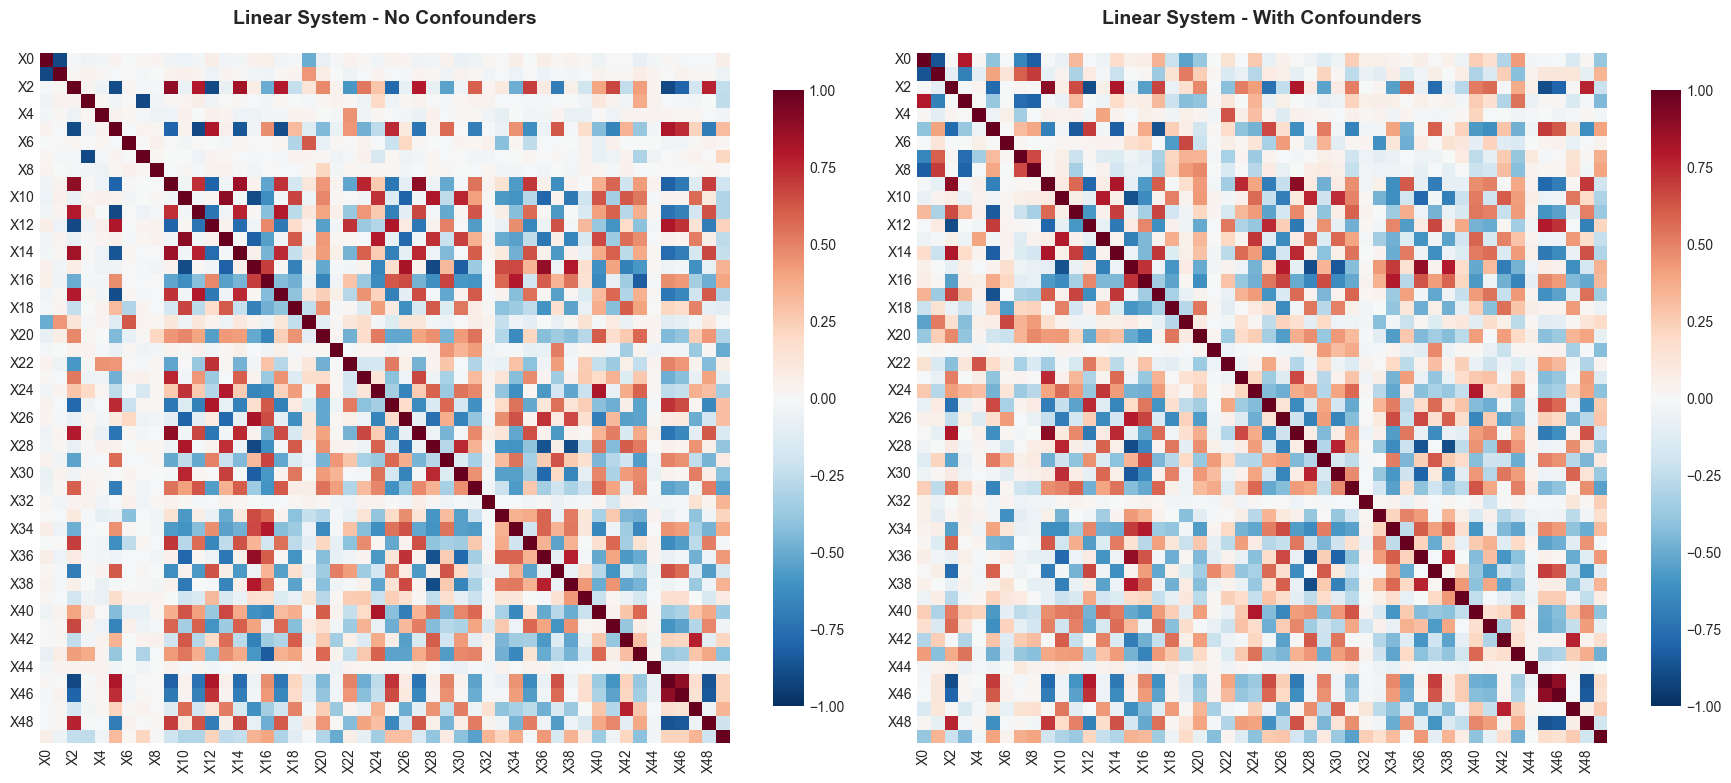

In [9]:
# Create side-by-side heatmaps for linear systems
n_features_show = 50

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# No confounders
sns.heatmap(corr_linear_no_conf.iloc[:n_features_show, :n_features_show],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Linear System - No Confounders\n', fontsize=14, fontweight='bold')

# With confounders
sns.heatmap(corr_linear_conf.iloc[:n_features_show, :n_features_show],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Linear System - With Confounders\n', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6. Algorithm Assumption Checks — PC and LiNGAM on Synthetic Data

This section evaluates whether the **theoretical assumptions** of each causal discovery algorithm are satisfied by each synthetic dataset variant, and what that implies for the quality of their outputs.

### PC (Peter-Clark) algorithm — key assumptions
| # | Assumption | Violation consequence |
|---|---|---|
| 1 | **Causal Markov & Faithfulness** | Systematic if paths cancel out |
| 2 | **Causal sufficiency** (no hidden confounders) | Spurious edges in `*_conf_*` datasets |
| 3 | **Fisher-z: Gaussian marginals** | False positives / false negatives in independence tests |
| 4 | **Fisher-z: sensitivity to n** | Over-detection at large n; misses at small n |

### LiNGAM (DirectLiNGAM) — key assumptions
| # | Assumption | Violation consequence |
|---|---|---|
| 1 | **Linear structural equations** | Wrong edge coefficients → wrong graph |
| 2 | **Non-Gaussian noise** (identification condition) | Graph is not identifiable from data |
| 3 | **Causal sufficiency** (no hidden confounders) | Spurious edges in `*_conf_*` datasets |

### What we check below
1. **Marginal Gaussianity** → Fisher-z validity for PC
2. **Fisher-z minimum detectable |r|** at training n → false-positive pressure on PC
3. **Linearity of structural equations** → LiNGAM's core SEM assumption
4. **Noise non-Gaussianity** (OLS residuals on true parent→child pairs) → LiNGAM identifiability


In [10]:

# ── Setup: load all 6 dataset variants + true adjacency matrices ──────────────
from scipy.stats import normaltest, skew, kurtosis
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from math import tanh, sqrt

ALL_DATASETS = [
    'linear_no_conf_f50_s1000_p50',
    'linear_conf_f50_s1000_p50',
    'nonlinear_no_conf_f50_s1000_p50',
    'nonlinear_conf_f50_s1000_p50',
    'mixed_no_conf_f50_s1000_p50',
    'mixed_conf_f50_s1000_p50',
]

DATASET_LABELS = {
    'linear_no_conf_f50_s1000_p50':    'Linear / no conf',
    'linear_conf_f50_s1000_p50':       'Linear / conf',
    'nonlinear_no_conf_f50_s1000_p50': 'Nonlinear / no conf',
    'nonlinear_conf_f50_s1000_p50':    'Nonlinear / conf',
    'mixed_no_conf_f50_s1000_p50':     'Mixed / no conf',
    'mixed_conf_f50_s1000_p50':        'Mixed / conf',
}

# Load train splits and true adjacency matrices
datasets_X    = {}
datasets_true = {}

for ds in ALL_DATASETS:
    df = pd.read_parquet(PROCESSED_DIR / f'{ds}_train.parquet')
    datasets_X[ds] = df.drop(columns=['Y'])
    adj = np.load(DATA_DIR / 'causal' / f'{ds}_true_full_adjacency.npy')
    datasets_true[ds] = adj[:-1, :-1]   # X-only block

n_feat = datasets_X[ALL_DATASETS[0]].shape[1]
n_train = len(datasets_X[ALL_DATASETS[0]])
print(f"Loaded {len(ALL_DATASETS)} datasets  |  n_train={n_train}  |  n_features={n_feat}")

# Min detectable |r| by Fisher-z at alpha=0.05 (two-sided) as function of n
def min_detectable_r(n, alpha=0.05):
    from scipy.stats import norm
    z_crit = norm.ppf(1 - alpha / 2)
    return tanh(z_crit / sqrt(n - 3))

print(f"\nFisher-z min detectable |r| at n={n_train}, α=0.05: {min_detectable_r(n_train):.4f}")


Loaded 6 datasets  |  n_train=800  |  n_features=50

Fisher-z min detectable |r| at n=800, α=0.05: 0.0693



Fisher-z detection threshold at n=800: |r| > 0.0693

Dataset                       % fail norm  % pairs |r|>thr False-pos risk    
────────────────────────────────────────────────────────────────────────────────
  Linear / no conf                     4%            56.3%  HIGH
  Linear / conf                       18%            66.6%  HIGH
  Nonlinear / no conf                 92%            72.2%  HIGH
  Nonlinear / conf                    94%            73.8%  HIGH
  Mixed / no conf                     86%            78.3%  HIGH
  Mixed / conf                        86%            74.0%  HIGH


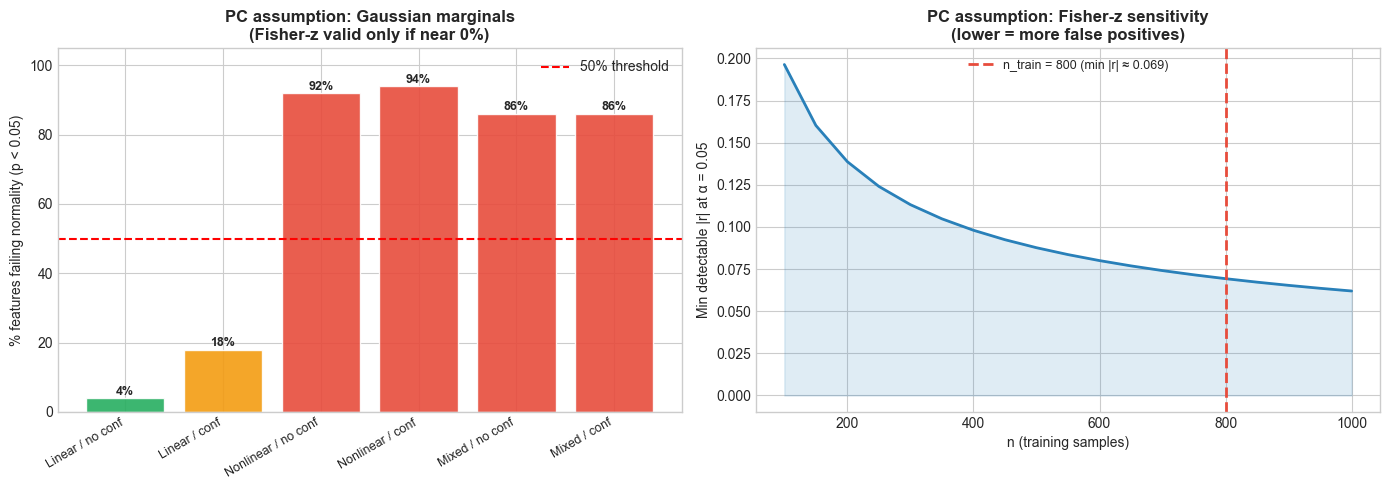

In [11]:

# ── Check 1: Marginal Gaussianity — Fisher-z validity for PC ─────────────────
# D'Agostino-Pearson k² test on each feature in each dataset.
# Gaussian marginals are a NECESSARY (not sufficient) condition for Fisher-z.

normality_results = {}

for ds, X in datasets_X.items():
    pvals = []
    for col in X.columns:
        _, p = normaltest(X[col].values)
        pvals.append(p)
    pct_fail = np.mean(np.array(pvals) < 0.05) * 100
    normality_results[ds] = {
        'pvals': pvals,
        'pct_fail': pct_fail,
        'median_p': float(np.median(pvals)),
    }

# ── Plot 1a: % features failing normality per dataset ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [DATASET_LABELS[ds] for ds in ALL_DATASETS]
pct_fail = [normality_results[ds]['pct_fail'] for ds in ALL_DATASETS]
colors_bar = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#27ae60'
              for p in pct_fail]

bars = axes[0].bar(range(len(ALL_DATASETS)), pct_fail, color=colors_bar, edgecolor='white', alpha=0.9)
axes[0].axhline(50, color='red', ls='--', lw=1.5, label='50% threshold')
axes[0].set_xticks(range(len(ALL_DATASETS)))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('% features failing normality (p < 0.05)')
axes[0].set_title('PC assumption: Gaussian marginals\n(Fisher-z valid only if near 0%)', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, pct in zip(bars, pct_fail):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{pct:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].legend()

# ── Plot 1b: Fisher-z minimum detectable |r| across n ─────────────────────────
ns = np.arange(100, 1001, 50)
min_rs = [min_detectable_r(n) for n in ns]
axes[1].plot(ns, min_rs, color='#2980b9', lw=2)
axes[1].axvline(n_train, color='#e74c3c', ls='--', lw=2,
                label=f'n_train = {n_train} (min |r| ≈ {min_detectable_r(n_train):.3f})')
axes[1].fill_between(ns, min_rs, alpha=0.15, color='#2980b9')
axes[1].set_xlabel('n (training samples)')
axes[1].set_ylabel('Min detectable |r| at α = 0.05')
axes[1].set_title('PC assumption: Fisher-z sensitivity\n(lower = more false positives)', fontweight='bold')
axes[1].legend(fontsize=9)

# Count how many feature pairs have |r| above the threshold (spurious detection risk)
threshold = min_detectable_r(n_train)
print(f"\nFisher-z detection threshold at n={n_train}: |r| > {threshold:.4f}")
print(f"\n{'Dataset':<28} {'% fail norm':>12} {'% pairs |r|>thr':>16} {'False-pos risk':<18}")
print("─" * 80)
for ds, X in datasets_X.items():
    corr_mat = X.corr().values
    upper = corr_mat[np.triu_indices(n_feat, k=1)]
    pct_above = np.mean(np.abs(upper) > threshold) * 100
    risk = "HIGH" if pct_above > 50 else "MEDIUM" if pct_above > 20 else "LOW"
    print(f"  {DATASET_LABELS[ds]:<26} {normality_results[ds]['pct_fail']:>11.0f}% {pct_above:>15.1f}%  {risk}")

plt.tight_layout()
plt.show()


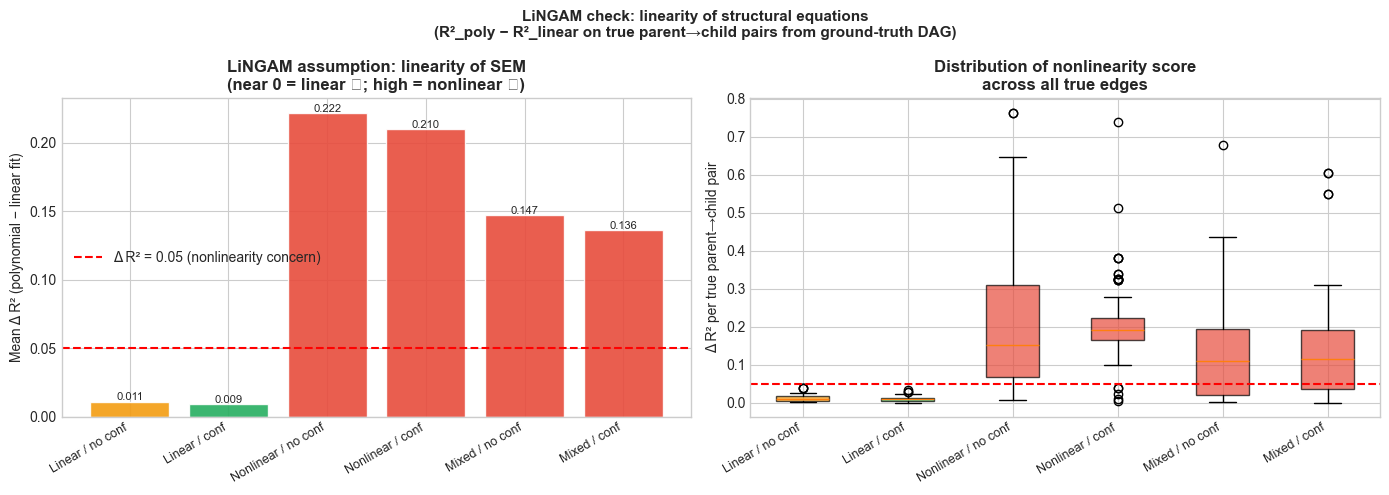


Dataset                       Mean R²_lin    Mean Δ R² Linearity verdict
──────────────────────────────────────────────────────────────────────
  Linear / no conf                  0.692        0.011  ~ mostly linear
  Linear / conf                     0.720        0.009  ✓ linear
  Nonlinear / no conf               0.466        0.222  ✗ nonlinear
  Nonlinear / conf                  0.525        0.210  ✗ nonlinear
  Mixed / no conf                   0.604        0.147  ✗ nonlinear
  Mixed / conf                      0.600        0.136  ✗ nonlinear


In [12]:

# ── Check 2: Linearity of structural equations — LiNGAM's core SEM assumption ─
# For each dataset, we sample true parent→child pairs from the true adjacency.
# We fit (a) a linear model and (b) a degree-2 polynomial, and compare R².
# High (R²_poly - R²_linear) = nonlinear relationship → LiNGAM assumption violated.

N_PAIRS_SAMPLE = 80    # max pairs to test per dataset (random sample for speed)
POLY_DEGREE    = 2

linearity_results = {}

rng = np.random.default_rng(42)

for ds, X in datasets_X.items():
    adj = datasets_true[ds]
    parent_child_pairs = [(i, j) for i in range(n_feat) for j in range(n_feat) if adj[i, j] == 1]

    if not parent_child_pairs:
        linearity_results[ds] = {'delta_r2': [], 'r2_linear': [], 'r2_poly': []}
        continue

    # Sample pairs if too many
    idx_sample = rng.choice(len(parent_child_pairs),
                            size=min(N_PAIRS_SAMPLE, len(parent_child_pairs)),
                            replace=False)
    pairs = [parent_child_pairs[i] for i in idx_sample]

    delta_r2s, r2_lins, r2_polys = [], [], []
    cols = X.columns.tolist()
    Xv = X.values

    for parent_i, child_j in pairs:
        # All true parents of child_j as regressors
        all_parents = [k for k in range(n_feat) if adj[k, child_j] == 1]
        x_in = Xv[:, all_parents]
        y_out = Xv[:, child_j]

        if x_in.shape[1] == 0:
            continue

        # Linear fit
        lr = LinearRegression().fit(x_in, y_out)
        r2_lin = r2_score(y_out, lr.predict(x_in))

        # Polynomial fit (degree 2, no interaction for speed)
        pf = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)
        x_poly = pf.fit_transform(x_in)
        lr_poly = LinearRegression().fit(x_poly, y_out)
        r2_poly = r2_score(y_out, lr_poly.predict(x_poly))

        delta_r2s.append(max(0, r2_poly - r2_lin))
        r2_lins.append(r2_lin)
        r2_polys.append(r2_poly)

    linearity_results[ds] = {
        'delta_r2': delta_r2s,
        'r2_linear': r2_lins,
        'r2_poly': r2_polys,
        'n_pairs': len(pairs),
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delta_R² per dataset (nonlinearity score)
mean_delta = [np.mean(linearity_results[ds]['delta_r2']) if linearity_results[ds]['delta_r2'] else 0
              for ds in ALL_DATASETS]
mean_r2_lin = [np.mean(linearity_results[ds]['r2_linear']) if linearity_results[ds]['r2_linear'] else 0
               for ds in ALL_DATASETS]

col_delta = ['#e74c3c' if d > 0.05 else '#f39c12' if d > 0.01 else '#27ae60'
             for d in mean_delta]
bars = axes[0].bar(range(len(ALL_DATASETS)), mean_delta, color=col_delta, edgecolor='white', alpha=0.9)
axes[0].axhline(0.05, color='red', ls='--', lw=1.5, label='Δ R² = 0.05 (nonlinearity concern)')
axes[0].set_xticks(range(len(ALL_DATASETS)))
axes[0].set_xticklabels([DATASET_LABELS[ds] for ds in ALL_DATASETS], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Mean Δ R² (polynomial − linear fit)')
axes[0].set_title('LiNGAM assumption: linearity of SEM\n(near 0 = linear ✓; high = nonlinear ✗)', fontweight='bold')
for bar, d in zip(bars, mean_delta):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f'{d:.3f}', ha='center', fontsize=8)
axes[0].legend()

# Boxplot of delta R² per dataset
data_box = [linearity_results[ds]['delta_r2'] for ds in ALL_DATASETS]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], col_delta):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0.05, color='red', ls='--', lw=1.5)
axes[1].set_xticks(range(1, len(ALL_DATASETS) + 1))
axes[1].set_xticklabels([DATASET_LABELS[ds] for ds in ALL_DATASETS], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Δ R² per true parent→child pair')
axes[1].set_title('Distribution of nonlinearity score\nacross all true edges', fontweight='bold')

plt.suptitle('LiNGAM check: linearity of structural equations\n'
             '(R²_poly − R²_linear on true parent→child pairs from ground-truth DAG)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'Dataset':<28} {'Mean R²_lin':>12} {'Mean Δ R²':>12} {'Linearity verdict'}")
print("─" * 70)
for ds in ALL_DATASETS:
    r = linearity_results[ds]
    d = np.mean(r['delta_r2']) if r['delta_r2'] else 0
    rlin = np.mean(r['r2_linear']) if r['r2_linear'] else 0
    v = "✓ linear" if d < 0.01 else "~ mostly linear" if d < 0.05 else "✗ nonlinear"
    print(f"  {DATASET_LABELS[ds]:<26} {rlin:>12.3f} {d:>12.3f}  {v}")


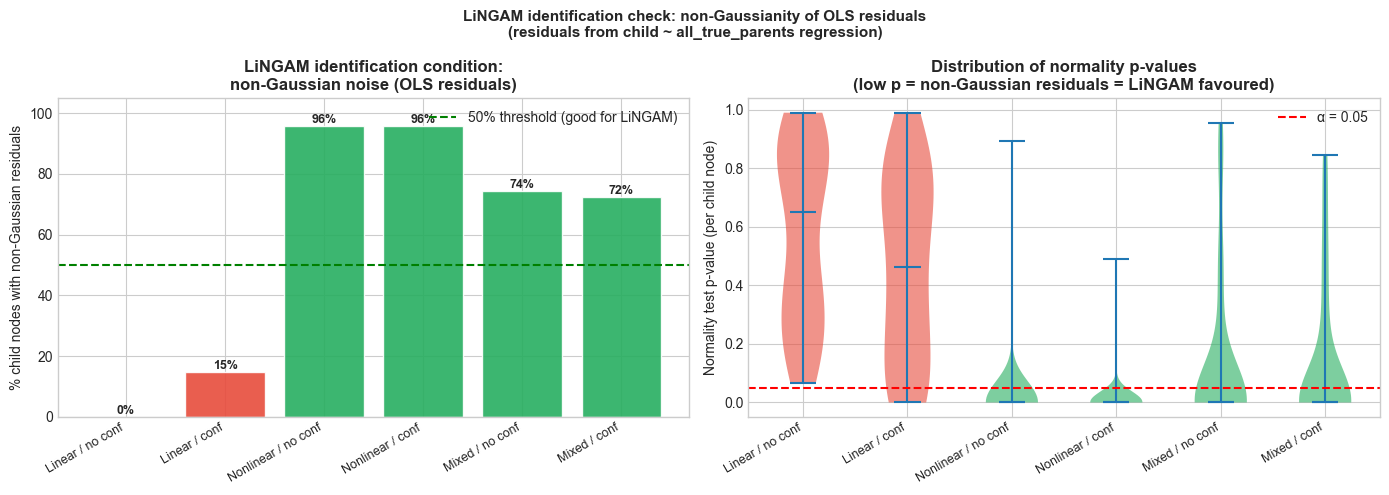


Dataset                       Nodes tested   % non-Gaussian LiNGAM identifiability
────────────────────────────────────────────────────────────────────────────────
  Linear / no conf                      47               0%  ✗ NOT identifiable (Gaussian noise)
  Linear / conf                         47              15%  ✗ NOT identifiable (Gaussian noise)
  Nonlinear / no conf                   47              96%  ✓ identifiable (non-Gaussian)
  Nonlinear / conf                      47              96%  ✓ identifiable (non-Gaussian)
  Mixed / no conf                       47              74%  ✓ identifiable (non-Gaussian)
  Mixed / conf                          47              72%  ✓ identifiable (non-Gaussian)

⚠️  Note: non-Gaussian residuals in nonlinear/mixed data are caused by the nonlinear
   structural equations, NOT non-Gaussian noise. LiNGAM 'benefits' from this, but it
   violates the linear SEM assumption simultaneously — it is identifying the wrong model.


In [13]:

# ── Check 3: Non-Gaussianity of noise — LiNGAM identification condition ───────
# LiNGAM is identified IFF noise terms are non-Gaussian.
# Proxy: fit OLS (child ~ all_true_parents), test residuals with D'Agostino-Pearson.
# Gaussian residuals → noise is Gaussian → LiNGAM NOT identified (Gaussian exception).
# Non-Gaussian residuals → either noise is non-Gaussian OR the linear SEM is wrong.

noise_results = {}

for ds, X in datasets_X.items():
    adj = datasets_true[ds]
    Xv  = X.values
    pvals_resid = []

    for child_j in range(n_feat):
        all_parents = [k for k in range(n_feat) if adj[k, child_j] == 1]
        if not all_parents:
            continue
        x_in = Xv[:, all_parents]
        y_out = Xv[:, child_j]
        resid = y_out - LinearRegression().fit(x_in, y_out).predict(x_in)
        _, p = normaltest(resid)
        pvals_resid.append(p)

    if not pvals_resid:
        noise_results[ds] = {'pct_nongauss': 0, 'pvals': []}
        continue

    pct_ng = np.mean(np.array(pvals_resid) < 0.05) * 100
    noise_results[ds] = {
        'pct_nongauss': pct_ng,
        'pvals': pvals_resid,
        'n_nodes_tested': len(pvals_resid),
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pct_ng = [noise_results[ds]['pct_nongauss'] for ds in ALL_DATASETS]
col_ng = ['#27ae60' if p > 50 else '#f39c12' if p > 20 else '#e74c3c' for p in pct_ng]

bars = axes[0].bar(range(len(ALL_DATASETS)), pct_ng, color=col_ng, edgecolor='white', alpha=0.9)
axes[0].axhline(50, color='green', ls='--', lw=1.5, label='50% threshold (good for LiNGAM)')
axes[0].set_xticks(range(len(ALL_DATASETS)))
axes[0].set_xticklabels([DATASET_LABELS[ds] for ds in ALL_DATASETS], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('% child nodes with non-Gaussian residuals')
axes[0].set_title('LiNGAM identification condition:\nnon-Gaussian noise (OLS residuals)', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, p in zip(bars, pct_ng):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].legend()

# P-value distributions as violin / boxplot
pval_data = [noise_results[ds]['pvals'] for ds in ALL_DATASETS]
vp = axes[1].violinplot(pval_data, positions=range(len(ALL_DATASETS)), showmedians=True)
for pc_patch, color in zip(vp['bodies'], col_ng):
    pc_patch.set_facecolor(color)
    pc_patch.set_alpha(0.6)
axes[1].axhline(0.05, color='red', ls='--', lw=1.5, label='α = 0.05')
axes[1].set_xticks(range(len(ALL_DATASETS)))
axes[1].set_xticklabels([DATASET_LABELS[ds] for ds in ALL_DATASETS], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Normality test p-value (per child node)')
axes[1].set_title('Distribution of normality p-values\n(low p = non-Gaussian residuals = LiNGAM favoured)', fontweight='bold')
axes[1].legend()

plt.suptitle("LiNGAM identification check: non-Gaussianity of OLS residuals\n"
             "(residuals from child ~ all_true_parents regression)",
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'Dataset':<28} {'Nodes tested':>13} {'% non-Gaussian':>16} {'LiNGAM identifiability'}")
print("─" * 80)
for ds in ALL_DATASETS:
    r = noise_results[ds]
    v = ("✓ identifiable (non-Gaussian)"  if r['pct_nongauss'] > 50
         else "~ marginal"                if r['pct_nongauss'] > 20
         else "✗ NOT identifiable (Gaussian noise)")
    print(f"  {DATASET_LABELS[ds]:<26} {r['n_nodes_tested']:>13} {r['pct_nongauss']:>15.0f}%  {v}")

print("\n⚠️  Note: non-Gaussian residuals in nonlinear/mixed data are caused by the nonlinear")
print("   structural equations, NOT non-Gaussian noise. LiNGAM 'benefits' from this, but it")
print("   violates the linear SEM assumption simultaneously — it is identifying the wrong model.")


In [14]:

# ── Check 4 (final): Assumption summary verdict table ─────────────────────────
# Aggregate all checks into a single pass/fail/partial table.

print("\n" + "=" * 100)
print("ALGORITHM ASSUMPTION VERDICT — SYNTHETIC DATASETS")
print("=" * 100)

header = (f"\n{'Dataset':<28} "
          f"{'PC: Gaussian':>14} "
          f"{'PC: FisherZ':>12} "
          f"{'PC: Sufficiency':>16} "
          f"{'LINGAM: Linear':>15} "
          f"{'LINGAM: NonGauss':>17} "
          f"{'LINGAM: Sufficiency':>20}")
print(header)
print("─" * 130)

for ds in ALL_DATASETS:
    has_conf = 'conf_f' in ds   # True for _conf_ datasets (note: _no_conf_ also contains 'conf')
    has_conf = '_no_conf_' not in ds

    # PC: Gaussian marginals
    pct_fail_norm = normality_results[ds]['pct_fail']
    pc_gauss = "✓ (<10%)"  if pct_fail_norm < 10 else "~ (10-50%)" if pct_fail_norm < 50 else "✗ (>50%)"

    # PC: Fisher-z sensitivity (what % of all pairs are "detectable"?)
    X = datasets_X[ds]
    corr_mat = X.corr().values
    upper = corr_mat[np.triu_indices(n_feat, k=1)]
    pct_above_thr = np.mean(np.abs(upper) > min_detectable_r(n_train)) * 100
    pc_fishz = "~ high" if pct_above_thr > 50 else "✓ ok"

    # PC: Causal sufficiency
    pc_suff = "✗ violated" if has_conf else "✓ satisfied"

    # LiNGAM: Linearity
    d = np.mean(linearity_results[ds]['delta_r2']) if linearity_results[ds]['delta_r2'] else 0
    ling_lin = "✓ (<0.01)" if d < 0.01 else "~ (0.01-0.05)" if d < 0.05 else "✗ (>0.05)"

    # LiNGAM: Non-Gaussian noise
    pct_ng = noise_results[ds]['pct_nongauss']
    ling_ng = "✓ (>50%)" if pct_ng > 50 else "~ (20-50%)" if pct_ng > 20 else "✗ (<20%)"

    # LiNGAM: Causal sufficiency
    ling_suff = "✗ violated" if has_conf else "✓ satisfied"

    print(f"  {DATASET_LABELS[ds]:<26} "
          f"{pc_gauss:>14} "
          f"{pc_fishz:>12} "
          f"{pc_suff:>16} "
          f"{ling_lin:>15} "
          f"{ling_ng:>17} "
          f"{ling_suff:>20}")

print("\n" + "─" * 100)
print("Legend: ✓ assumption met  |  ~ partially met  |  ✗ assumption violated")
print()
print("Key insights:")
print("  • Linear datasets  → Gaussian noise → LiNGAM's non-Gaussianity condition is NOT met")
print("    (LiNGAM cannot identify a linear-Gaussian SEM without additional constraints)")
print("  • Nonlinear datasets → non-Gaussian OLS residuals → LiNGAM identification condition")
print("    appears met, BUT the linear SEM assumption is violated simultaneously")
print("  • Mixed datasets   → both algorithms face partial violations")
print("  • *_conf_* datasets → causal sufficiency violated for BOTH PC and LiNGAM")
print("  • PC at n=800: min detectable |r| ≈ {:.3f} → small spurious correlations are 'significant'".format(
      min_detectable_r(n_train)))
print("=" * 100)



ALGORITHM ASSUMPTION VERDICT — SYNTHETIC DATASETS

Dataset                        PC: Gaussian  PC: FisherZ  PC: Sufficiency  LINGAM: Linear  LINGAM: NonGauss  LINGAM: Sufficiency
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Linear / no conf                 ✓ (<10%)       ~ high      ✓ satisfied   ~ (0.01-0.05)          ✗ (<20%)          ✓ satisfied
  Linear / conf                  ~ (10-50%)       ~ high       ✗ violated       ✓ (<0.01)          ✗ (<20%)           ✗ violated
  Nonlinear / no conf              ✗ (>50%)       ~ high      ✓ satisfied       ✗ (>0.05)          ✓ (>50%)          ✓ satisfied
  Nonlinear / conf                 ✗ (>50%)       ~ high       ✗ violated       ✗ (>0.05)          ✓ (>50%)           ✗ violated
  Mixed / no conf                  ✗ (>50%)       ~ high      ✓ satisfied       ✗ (>0.05)          ✓ (>50%)          ✓ satisfied
  Mixed / conf                     ✗ (>50%)

---
## 7. Adjacency Matrix Comparison — True vs Discovered (p30 datasets)

Visual comparison of the ground-truth X→X adjacency vs the PC and LiNGAM discovered graphs for the new sparser datasets (`edge_probability=0.07`, `y_parents_ratio=0.3`).


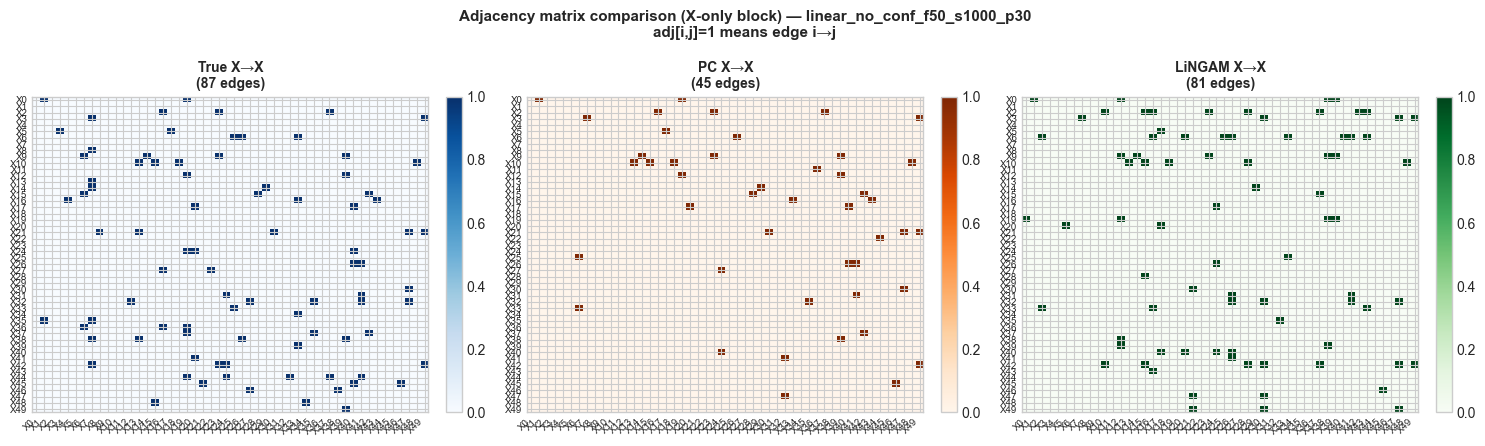

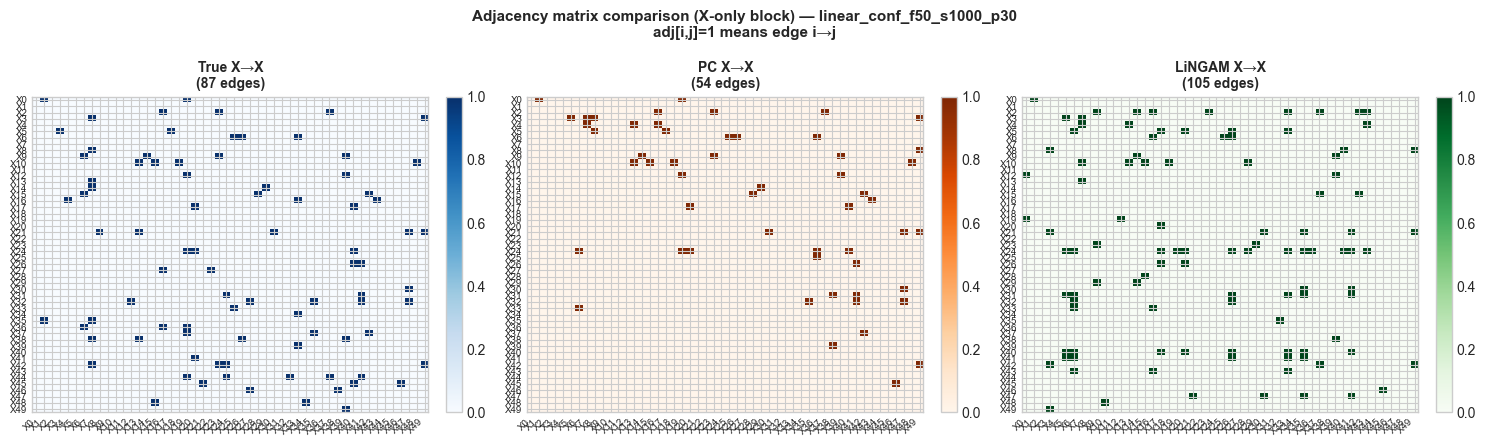

In [16]:
import matplotlib.pyplot as plt
import numpy as np

CAUSAL_DIR = DATA_DIR / 'causal'
P30_DATASETS = [
    'linear_no_conf_f50_s1000_p30',
    'linear_conf_f50_s1000_p30',
]

for DATASET in P30_DATASETS:
    # Load adjacency matrices
    true_full      = np.load(CAUSAL_DIR / f'{DATASET}_true_full_adjacency.npy')
    pc_train_adj_xx     = np.load(CAUSAL_DIR / f'{DATASET}_pc_train_adjacency.npy')
    lingam_train_adj_xx = np.load(CAUSAL_DIR / f'{DATASET}_lingam_train_adjacency.npy')

    # X-only block of the true full adjacency (exclude Y column/row)
    true_adj_xx = true_full[:-1, :-1]

    n_features   = true_adj_xx.shape[0]
    feature_names = [f'X{i}' for i in range(n_features)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, mat, title, cmap in [
        (axes[0], true_adj_xx,         "True X→X",   "Blues"),
        (axes[1], pc_train_adj_xx,     "PC X→X",     "Oranges"),
        (axes[2], lingam_train_adj_xx, "LiNGAM X→X", "Greens"),
    ]:
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(n_features))
        ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(n_features))
        ax.set_yticklabels(feature_names, fontsize=7)
        ax.set_title(f"{title}\n({int(mat.sum())} edges)", fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(
        f"Adjacency matrix comparison (X-only block) — {DATASET}\nadj[i,j]=1 means edge i→j",
        fontweight='bold', fontsize=11
    )
    plt.tight_layout()
    plt.show()
